In [2]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Common period of all datasets

In [3]:
iyear = 1981
fyear = 2015

# Datasets used

In [4]:
models = ['APHRO','CHIRPS','CRU','ERA5','GPCP','HARv2']

# Subregions 

In [5]:
domains = ['HMA','HK','SL','TP','CH','SEH']

# Precipitation (tp) datasets loading

Monthly mean are computed and converted to mm per month. For more details of this part, go to : '/home/bricej/MyPythonLibrary/StageM2_IVT/script/compute_tp_datasets_mm_month'

In [6]:
tp_datasets = {} # dictionnary to store precipitation datasets

# path of the files for the different datasets
files = {
    'APHRO': 'tp_HMA_1951-2015_APHRO.nc',
    'GPCP': 'tp_HMA_1891-2019_GPCP.nc',
    'CRU': 'tp_HMA_1901-2020_CRU.nc',
    'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
    'HARv2': 'tp_HMA_1980-2023_HARv2.nc',
    'ERA5': 'tp_HMA_1940-2025_ERA5.nc'
}
path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/' # path + files = precipitation datasets

# function to reduce the domain taken for HARv2 dataset because of its special coordinates
def xy_sel_dom(ds,latS,latN,lonW,lonE):
    #latS,latN,lonW,lonE=coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

# data storing in tp_datasets
for model in models: # for every dataset
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp'] # open dataset
    tp_model=tp_model.sel(time=slice(str(iyear),str(fyear))) # take only the 1981-2015 period
    
    for domain in domains: # and for every subregions
        if model == 'HARv2':
            latS,latN,lonW,lonE = coord_domain(domain)
            tp_datasets[model][domain]=xy_sel_dom(tp_model,latS,latN,lonW,lonE) # reduce the domain taken for HARv2 with the function
        else:
            tp_datasets[model][domain] = field_dom(tp_model,domain) # reduce the domain taken for the other datasets

# Monthly mean (temporally and spatially) over the different subregions

In [7]:
tp_mean_dict = {} # dictionnary to store the monthly mean precipitation datasets

for model in models: # for every dataset
    tp_mean_dict[model]={}
    for domain in domains: # for every subregions
        tp_mean_dict[model][domain] = tp_datasets[model][domain].groupby('time.month').mean('time', skipna=True) # temporal mean
        if model == 'HARv2':
            tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['south_north','west_east'], skipna=True) # spatial mean
        else:
            tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['lat','lon'], skipna=True) # spatial mean

# Final plot

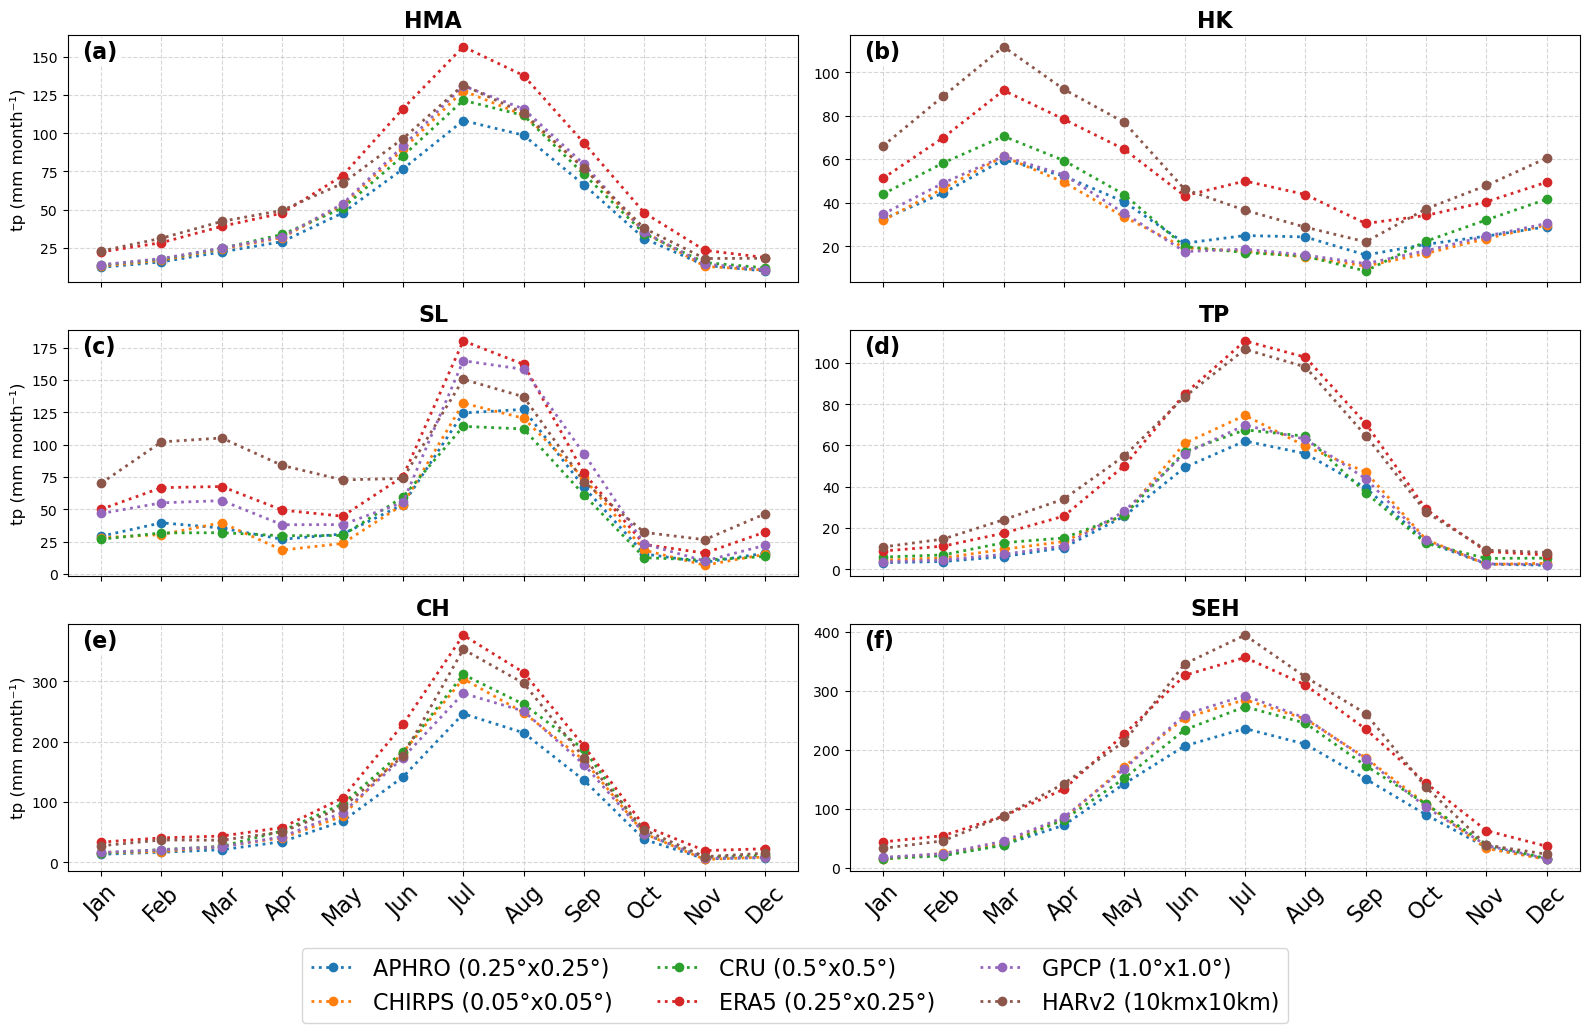

In [8]:
# month of the year
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# spatial resolution for the datasets for the legend
resolutions = {'APHRO': '0.25°x0.25°',
               'GPCP': '1.0°x1.0°',
               'CRU': '0.5°x0.5°',
               'CHIRPS': '0.05°x0.05°',
               'HARv2': '10kmx10km',
               'ERA5': '0.25°x0.25°'}

# letters for the subplots
letters = ['a', 'b', 'c', 'd', 'e', 'f']

# figure
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

# subplot for every domain
for i, dom in enumerate(domains):

    ax = axes[i]

    # and for every subplot, all datasets are ploted
    for model in models:
        da = tp_mean_dict[model][dom] # monthly mean data
        ax.plot(da['month'], da.values, marker='o', linestyle=':', label=f'{model} ({resolutions[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold") # domain label for the subplot
    ax.set_xticks(range(1,13)) # un tick par mois : 1 -> 12
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12) # y ax label
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16) # xlabel for the months of the year
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False) # pas de xlabel pour les autres lignes
    
    ax.grid(True, linestyle='--', alpha=0.5)

    # letter for the subplot top-left
    ax.text(0.02, 0.98,f'({letters[i]})',transform=ax.transAxes,fontsize=16,fontweight='bold',va='top',ha='left',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2))

# legend
handles, labels = axes[0].get_legend_handles_labels() # récupérer la légénde du premier subplot
fig.legend(handles,labels,loc='lower center',bbox_to_anchor=(0.5, -0.04),ncol=3,fontsize=16,frameon=True) # légende au milieu en dessous

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

Figure 3. Annual cycle of precipitation over the common available period 1981-2015 for the different datasets : characteristics of the datasets present in the legend are provided in Table 1. Precipitation (tp, mm.month-1). High Mountain Asia (HMA). Subfigures (b-f) represent subregions (see Fig. 2). 